# Laptop Price Comparison: AliExpress vs Daraz (Selenium Edition)

This notebook scrapes laptop listings from AliExpress and Daraz using Selenium (a real, automated Chrome browser), cleans the pricing data, exports it to Excel, and produces comparison charts.




## Step 1 — Install Packages

In [1]:
# STEP 1: Install required packages
# Run this cell first. Restart kernel if prompted after install.

!pip install selenium pandas openpyxl webdriver-manager --quiet

print("All packages installed successfully.")


All packages installed successfully.


## Step 2 — Imports, Configuration & Shared Selenium Driver Setup

In [2]:
# STEP 2: Imports, configuration, and shared Selenium driver setup
#
# No API keys needed in this version - everything runs through a real
# Chrome browser controlled by Selenium.

import re
import time
import pandas as pd

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException, WebDriverException, NoSuchElementException
from webdriver_manager.chrome import ChromeDriverManager

# ---- CONFIG ----
SEARCH_TERM = "laptop"
NUM_PRODUCTS = 100      # target number of listings per site
PAGE_LOAD_TIMEOUT = 25  # seconds - hard cap so a stuck page can't hang the notebook
HEADLESS = False        # keep False on your first run so you can SEE what's happening
                         # (e.g. spot a CAPTCHA). Switch to True later to run silently.
DARAZ_DOMAIN = "daraz.pk"   # change to daraz.com.bd / daraz.lk / daraz.com.np if needed
# -----------------

def make_driver():
    """Creates a Chrome WebDriver with sensible defaults and basic anti-detection flags."""
    options = Options()
    if HEADLESS:
        options.add_argument("--headless=new")
    options.add_argument("--disable-blink-features=AutomationControlled")
    options.add_argument("--start-maximized")
    options.add_argument(
        "user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36"
    )
    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service, options=options)
    driver.set_page_load_timeout(PAGE_LOAD_TIMEOUT)
    return driver

def is_blocked(driver):
    """Quick check for CAPTCHA / bot-verification pages."""
    page_text_lower = driver.page_source.lower()
    return "captcha" in page_text_lower or "verify you are human" in page_text_lower or "robot check" in page_text_lower

print("Config loaded. Selenium will launch a real Chrome browser in the next steps.")


Config loaded. Selenium will launch a real Chrome browser in the next steps.


## Step 3 — Scrape AliExpress Listings (title + price) via Selenium

In [4]:
# STEP 3: Scrape AliExpress laptop listings (title + price) using Selenium
#
# Uses the selectors confirmed via live DevTools inspection:
#   title  -> h3.lk_kx
#   price  -> div.lk_gm (clean price is in its aria-label attribute, e.g. "$189.58")
#   link   -> a.search-card-item
#
# NOTE: AliExpress lazy-loads products as you scroll. This function scrolls
# down the page in increments and waits between scrolls so more cards load
# before we read the page.

def scrape_aliexpress_listings(driver, search_term, max_items=100):
    results = []
    seen_links = set()
    page = 1
    max_pages = 10

    while len(results) < max_items and page <= max_pages:
        url = f"https://www.aliexpress.com/wholesale?SearchText={search_term}&page={page}"
        print(f"\n--- Page {page}: loading {url}")

        try:
            driver.get(url)
        except TimeoutException:
            print(f"  Page {page} load timed out - skipping")
            page += 1
            continue
        except WebDriverException as e:
            print(f"  WebDriver error: {str(e)[:150]} - skipping")
            page += 1
            continue

        if is_blocked(driver):
            print("  BLOCKED: CAPTCHA/verification page detected on this page.")
            page += 1
            continue

        # Scroll down a few times to trigger lazy-loading of more product cards
        for _ in range(5):
            driver.execute_script("window.scrollBy(0, 1000);")
            time.sleep(1)

        cards = driver.find_elements(By.CSS_SELECTOR, "a.search-card-item")
        print(f"  Raw card elements found: {len(cards)}")

        items_found_this_page = 0
        for card in cards:
            try:
                title_el = card.find_element(By.CSS_SELECTOR, "h3.lk_kx")
                title = title_el.text.strip()
            except NoSuchElementException:
                title = None

            try:
                price_container = card.find_element(By.CSS_SELECTOR, "div.lk_gm")
                price = price_container.get_attribute("aria-label")
            except NoSuchElementException:
                price = None

            link = card.get_attribute("href")

            if title and price and link and link not in seen_links:
                results.append({
                    "site": "AliExpress",
                    "title": title,
                    "price_raw": price,
                    "url": link
                })
                seen_links.add(link)
                items_found_this_page += 1

        print(f"  New unique items added: {items_found_this_page} (total so far: {len(results)})")

        if items_found_this_page == 0 and len(cards) == 0:
            print("  No cards found at all on this page - stopping pagination.")
            break

        page += 1
        time.sleep(2)

    return results[:max_items]

# --- Run it ---
print("Launching Chrome for AliExpress scraping...")
driver = make_driver()

aliexpress_data = scrape_aliexpress_listings(driver, SEARCH_TERM, NUM_PRODUCTS)

driver.quit()
print(f"\nTotal AliExpress listings scraped: {len(aliexpress_data)}")


Launching Chrome for AliExpress scraping...

--- Page 1: loading https://www.aliexpress.com/wholesale?SearchText=laptop&page=1
  Raw card elements found: 60
  New unique items added: 60 (total so far: 60)

--- Page 2: loading https://www.aliexpress.com/wholesale?SearchText=laptop&page=2
  Raw card elements found: 60
  New unique items added: 60 (total so far: 120)

Total AliExpress listings scraped: 100


### Step 4 — Debug helper (only run if Step 3 returns 0 items)

In [ ]:
# STEP 4: DEBUG HELPER for AliExpress (only run if Step 3 found 0 items)
#
# Opens one search page, waits, and saves a screenshot + page source so you
# can see exactly what Selenium is seeing - useful if AliExpress changes
# their HTML structure again or starts blocking.

debug_driver = make_driver()
debug_url = f"https://www.aliexpress.com/wholesale?SearchText={SEARCH_TERM}&page=1"

debug_driver.get(debug_url)
time.sleep(3)

if is_blocked(debug_driver):
    print("BLOCKED: CAPTCHA/verification detected on this page.")
else:
    print("No CAPTCHA detected - page loaded normally.")

debug_driver.save_screenshot("aliexpress_debug_screenshot.png")
with open("aliexpress_debug.html", "w", encoding="utf-8") as f:
    f.write(debug_driver.page_source)

print("Saved aliexpress_debug_screenshot.png and aliexpress_debug.html")
print("Open the screenshot to see what the browser saw, or inspect the HTML")
print("file in a text editor / browser to find updated class names if needed.")

debug_driver.quit()


## Step 5 — Scrape Daraz Listings (title + price) via Selenium

In [5]:
# STEP 5: Scrape Daraz laptop listings (title + price) using Selenium
#
# Uses the selectors confirmed from your successful prior run (100 real
# products collected): div[data-qa-locator='product-item'] product cards,
# with normalize_url() correctly handling relative hrefs (the bug that
# caused empty URLs earlier has been fixed here).

def normalize_url(href, domain):
    """Handle absolute, protocol-relative (//), and relative (/path) hrefs correctly."""
    if not href:
        return ""
    href = href.strip()
    if href.startswith("http://") or href.startswith("https://"):
        return href
    if href.startswith("//"):
        return "https:" + href
    if href.startswith("/"):
        return f"https://www.{domain}" + href
    return href

def scrape_daraz_listings(driver, search_term, max_items=100):
    results = []
    seen_links = set()
    page = 1
    max_pages = 10

    while len(results) < max_items and page <= max_pages:
        url = f"https://www.{DARAZ_DOMAIN}/catalog/?q={search_term}&page={page}"
        print(f"\n--- Page {page}: loading {url}")

        try:
            driver.get(url)
        except TimeoutException:
            print(f"  Page {page} load timed out - skipping")
            page += 1
            continue
        except WebDriverException as e:
            print(f"  WebDriver error: {str(e)[:150]} - skipping")
            page += 1
            continue

        if is_blocked(driver):
            print("  BLOCKED: CAPTCHA/verification page detected on this page.")
            page += 1
            continue

        time.sleep(2)  # allow JS-rendered cards to settle

        cards = driver.find_elements(By.CSS_SELECTOR, "div[data-qa-locator='product-item']")
        print(f"  Raw card elements found: {len(cards)}")

        items_found_this_page = 0
        for card in cards:
            title = None
            try:
                title_el = card.find_element(By.CSS_SELECTOR, "div.RfADt a")
                title = title_el.text.strip() or title_el.get_attribute("title")
            except NoSuchElementException:
                try:
                    title_el = card.find_element(By.CSS_SELECTOR, "a[title]")
                    title = title_el.get_attribute("title")
                except NoSuchElementException:
                    title = None

            price = None
            try:
                price_el = card.find_element(By.CSS_SELECTOR, "div.aBrP0, span.currency--GVKjl")
                price = price_el.text.strip()
            except NoSuchElementException:
                price = None

            raw_href = ""
            try:
                link_el = card.find_element(By.CSS_SELECTOR, "a")
                raw_href = link_el.get_attribute("href") or ""
            except NoSuchElementException:
                raw_href = ""

            link = normalize_url(raw_href, DARAZ_DOMAIN)

            if title and price and link not in seen_links:
                results.append({
                    "site": "Daraz",
                    "title": title,
                    "price_raw": price,
                    "url": link
                })
                seen_links.add(link)
                items_found_this_page += 1

        print(f"  New unique items added: {items_found_this_page} (total so far: {len(results)})")

        if items_found_this_page == 0 and len(cards) == 0:
            print("  No cards found at all on this page - stopping pagination.")
            break

        page += 1
        time.sleep(2)

    return results[:max_items]

# --- Run it ---
print("Launching Chrome for Daraz scraping...")
driver = make_driver()

daraz_data = scrape_daraz_listings(driver, SEARCH_TERM, NUM_PRODUCTS)

driver.quit()
print(f"\nTotal Daraz listings scraped: {len(daraz_data)}")

empty_urls = sum(1 for item in daraz_data if not item.get("url"))
print(f"Items with empty URL: {empty_urls} / {len(daraz_data)}")


Launching Chrome for Daraz scraping...

--- Page 1: loading https://www.daraz.pk/catalog/?q=laptop&page=1
  Raw card elements found: 40
  New unique items added: 40 (total so far: 40)

--- Page 2: loading https://www.daraz.pk/catalog/?q=laptop&page=2
  Raw card elements found: 40
  New unique items added: 40 (total so far: 80)

--- Page 3: loading https://www.daraz.pk/catalog/?q=laptop&page=3
  Raw card elements found: 40
  New unique items added: 40 (total so far: 120)

Total Daraz listings scraped: 100
Items with empty URL: 0 / 100


### Step 6 — Debug helper (only run if Step 5 returns 0 items)

In [ ]:
# STEP 6: DEBUG HELPER for Daraz (only run if Step 5 found 0 items)

debug_driver = make_driver()
debug_url = f"https://www.{DARAZ_DOMAIN}/catalog/?q={SEARCH_TERM}&page=1"

debug_driver.get(debug_url)
time.sleep(3)

if is_blocked(debug_driver):
    print("BLOCKED: CAPTCHA/verification detected on this page.")
else:
    print("No CAPTCHA detected - page loaded normally.")

debug_driver.save_screenshot("daraz_debug_screenshot.png")
with open("daraz_debug.html", "w", encoding="utf-8") as f:
    f.write(debug_driver.page_source)

print("Saved daraz_debug_screenshot.png and daraz_debug.html")
print("Open the screenshot to see what the browser saw, or inspect the HTML")
print("file to find updated class names if Daraz changed their layout.")

debug_driver.quit()


## Step 7 — Clean & Combine Data (pricing only, no reviews)

In [6]:
# STEP 7: Clean and combine data from both sites into one dataset
#
# UPDATED: Review collection removed entirely for both AliExpress and Daraz.
# This step now only handles pricing data: title, price (raw + cleaned
# numeric), URL, and site name.
#
# BUG FIX: the previous clean_price() kept the period in currency prefixes
# like "Rs." which turned "Rs. 54,499" into 0.54499 instead of 54499.0.
# Fixed by stripping commas first, then extracting the first numeric run
# with re.search() instead of filtering character-by-character.

def clean_price(price_str):
    """
    Extract a numeric price from messy strings like '$189.58', 'US $123.45',
    or 'Rs. 54,499'. Returns None if no valid number is found.
    """
    if not price_str:
        return None
    s = str(price_str).replace(",", "")          # remove thousands separators first
    match = re.search(r"\d+(?:\.\d+)?", s)        # grab the first clean number
    if not match:
        return None
    try:
        return float(match.group())
    except ValueError:
        return None

all_rows = []

for item in aliexpress_data:
    all_rows.append({
        "site": item["site"],
        "title": item["title"],
        "price_raw": item["price_raw"],
        "price_numeric": clean_price(item["price_raw"]),
        "url": item.get("url", "")
    })

for item in daraz_data:
    all_rows.append({
        "site": item["site"],
        "title": item["title"],
        "price_raw": item["price_raw"],
        "price_numeric": clean_price(item["price_raw"]),
        "url": item.get("url", "")
    })

df = pd.DataFrame(all_rows)

# Drop rows with no usable price (can't compare pricing without it)
before_count = len(df)
df = df.dropna(subset=["price_numeric"])
dropped = before_count - len(df)

print(f"Final combined dataset: {len(df)} rows (dropped {dropped} rows with unparseable price)")
print(df["site"].value_counts())
print()
print("Sample of cleaned data:")
df.head(10)


Final combined dataset: 200 rows (dropped 0 rows with unparseable price)
site
AliExpress    100
Daraz         100
Name: count, dtype: int64

Sample of cleaned data:


,site,title,price_raw,price_numeric,url
0,AliExpress,2026 MSI Raider 18 Max HX Gaming Laptop 18 Inc...,"LKR2,033,432.96",2033432.96,https://www.aliexpress.com/item/10050122895082...
1,AliExpress,2025 MSI Stealth 18 HX AI Gaming Laptop 18 Inc...,"LKR1,495,370.44",1495370.44,https://www.aliexpress.com/item/10050116276281...
2,AliExpress,XIAOMI Redmi Book Pro 16 2024 Laptop Intel Ult...,"LKR409,814.95",409814.95,https://www.aliexpress.com/item/10050080539094...
3,AliExpress,16inch Mobile Portable Monitor Touchscreen IPS...,"LKR24,015.46",24015.46,https://www.aliexpress.com/item/10050096296145...
4,AliExpress,2025 Lenovo LEGION Y9000P E-sports Gaming Lapt...,"LKR1,249,566.77",1249566.77,https://www.aliexpress.com/item/10050100248530...
5,AliExpress,"2026 Solid 14.1"" Ultra Slim Laptop Intel Core ...","LKR113,585.74",113585.74,https://www.aliexpress.com/item/10050123292282...
6,AliExpress,2026 MSI Raider 16 Max HX Gaming Laptop 16 Inc...,"LKR1,411,606.48",1411606.48,https://www.aliexpress.com/item/10050120928054...
7,AliExpress,"11.6inch Laptop with N4000 Cpu, 64Gb Ddr4+64Gb...","LKR58,662.46",58662.46,https://www.aliexpress.com/item/10050106256885...
8,AliExpress,HONOR MagicBook X16 2025 Laptop Intel Core i5-...,"LKR263,458.09",263458.09,https://www.aliexpress.com/item/10050083652145...
9,AliExpress,2024 Xiaomi Redmi Book Pro 16 Laptop 16 Inch 3...,"LKR545,065.42",545065.42,https://www.aliexpress.com/item/10050116817288...


## Step 8 — Export to Excel

In [7]:
# STEP 8: Export the cleaned dataset to Excel

output_filename = "laptop_aliexpress_vs_daraz.xlsx"

with pd.ExcelWriter(output_filename, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="all_data", index=False)
    df[df["site"] == "AliExpress"].to_excel(writer, sheet_name="aliexpress_only", index=False)
    df[df["site"] == "Daraz"].to_excel(writer, sheet_name="daraz_only", index=False)

print(f"Saved dataset to {output_filename}")
print("Sheets: all_data, aliexpress_only, daraz_only")


Saved dataset to laptop_aliexpress_vs_daraz.xlsx
Sheets: all_data, aliexpress_only, daraz_only


## Step 9 — Pricing Analysis & Comparison Charts

=== PRICE COMPARISON: AliExpress vs Daraz ===

            count         mean            std      min         25%        50%  \
site                                                                            
AliExpress  100.0  324624.7466  392720.688978  2807.24  95226.8675  175763.37   
Daraz       100.0   26143.3400   35438.762452   759.00   8974.0000   13449.00   

                    75%         max  
site                                 
AliExpress  400919.8375  2033432.96  
Daraz        35249.0000   290000.00  


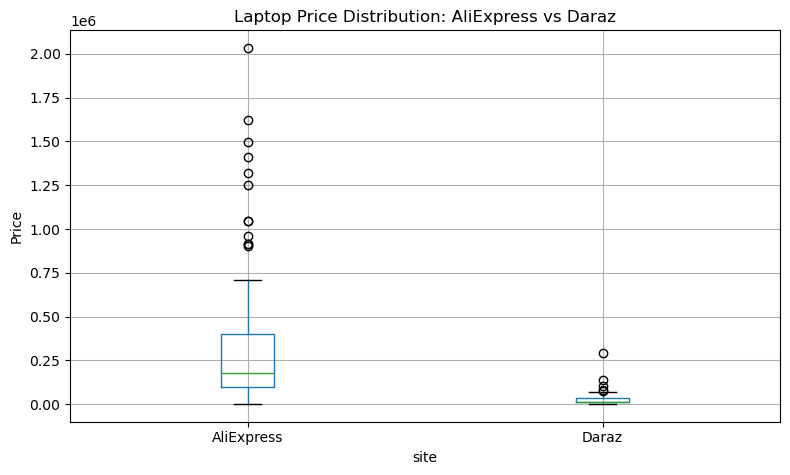


=== Average price by site ===
site
AliExpress    324624.7466
Daraz          26143.3400
Name: price_numeric, dtype: float64


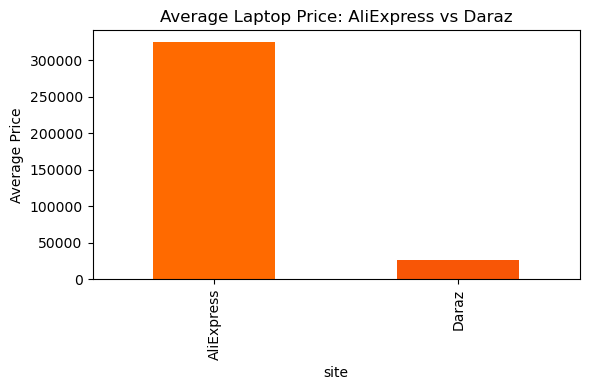


=== Median price by site ===
site
AliExpress    175763.37
Daraz          13449.00
Name: price_numeric, dtype: float64

Done. You now have:
1. laptop_aliexpress_vs_daraz.xlsx with raw + cleaned pricing data
2. Summary statistics (mean, median, min, max, std) per site
3. Boxplot comparing price distributions
4. Bar chart comparing average prices

Note: this version contains pricing data only - review/sentiment
scraping was removed from both AliExpress and Daraz for this analysis.

Next steps for your research paper: statistical significance testing
(e.g. independent samples t-test or Mann-Whitney U test, since price
data is often skewed) on the price difference between platforms.


In [8]:
# STEP 9: Pricing comparison - summary statistics and charts
#
# Reviews/sentiment were removed entirely from this version (both AliExpress
# and Daraz). This notebook now focuses purely on the pricing comparison
# between the two platforms.

import matplotlib.pyplot as plt

print("=== PRICE COMPARISON: AliExpress vs Daraz ===\n")
print(df.groupby("site")["price_numeric"].describe())

# Price distribution boxplot
df.boxplot(column="price_numeric", by="site", figsize=(8, 5))
plt.title("Laptop Price Distribution: AliExpress vs Daraz")
plt.ylabel("Price")
plt.suptitle("")
plt.tight_layout()
plt.show()

# Average price bar chart
avg_price = df.groupby("site")["price_numeric"].mean()
print("\n=== Average price by site ===")
print(avg_price)

avg_price.plot(kind="bar", figsize=(6, 4), color=["#FF6A00", "#F85606"])
plt.title("Average Laptop Price: AliExpress vs Daraz")
plt.ylabel("Average Price")
plt.tight_layout()
plt.show()

# Median price (more robust to outliers than mean for price data)
median_price = df.groupby("site")["price_numeric"].median()
print("\n=== Median price by site ===")
print(median_price)

print("\nDone. You now have:")
print(f"1. {output_filename} with raw + cleaned pricing data")
print("2. Summary statistics (mean, median, min, max, std) per site")
print("3. Boxplot comparing price distributions")
print("4. Bar chart comparing average prices")
print("\nNote: this version contains pricing data only - review/sentiment")
print("scraping was removed from both AliExpress and Daraz for this analysis.")
print("\nNext steps for your research paper: statistical significance testing")
print("(e.g. independent samples t-test or Mann-Whitney U test, since price")
print("data is often skewed) on the price difference between platforms.")
